In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# set project root
PROJECT_DIR = Path(r"C:\Users\hseyed\Documents\Python\Monkey_face_Self\AU_analysis")
#ROJECT_DIR = Path(r"/Users/reza/Documents/Python/DLC_AU_analysis/Monkey_face_Self")

sys.path.append(str(PROJECT_DIR))

from src.alignment import time_sync
from src.features import geometry, temporal
from src.modeling import modeling
from src.utils import utils_plots

import re
import yaml

DATA_DIR = PROJECT_DIR / "data"
CONFIG_DIR = PROJECT_DIR / "config"


behav_files = list(DATA_DIR.glob("*.mat"))
file_path = behav_files[0]

csv_files = list(DATA_DIR.glob("*.csv"))[0]
csv_pd = pd.read_csv(csv_files, header=[0, 1, 2])
csv_pd.columns = csv_pd.columns.droplevel(0)
behave_pd = pd.read_pickle(DATA_DIR/"behave_pd.pkl")

# Video Dir 
video_files = list(DATA_DIR.glob("*.mp4"))[0]
video_meta = time_sync.get_video_info(video_files)
fps = video_meta["fps"]

config_path = CONFIG_DIR / "config.yaml"

# Config parameters
with open(config_path,"r") as f:
    config = yaml.safe_load(f)

# extract parameters
target_code = config["target_code"]
window_sec = config["window_sec"]
baseline_window = config["baseline_window"]
AUs = config["AU"]
likelihood_threshold = config["likelihood_threshold"]
n_splits = config["n_splits"]
model_type = config["model_type"]


In [2]:
# building datasets

df_feature_flatten = temporal.build_dataset_flatten(
    trial_df=behave_pd,
    csv_pd=csv_pd,
    au_config=AUs,
    fps=fps,
    likelihood_threshold=likelihood_threshold,
    baseline_window=baseline_window
)

df_feature = temporal.dataset_to_long_format(df_feature_flatten)

df_feature_flatten.to_pickle(DATA_DIR/"feature_flatten_df.pkl")
df_feature.to_pickle(DATA_DIR/"feature_df.pkl")

In [3]:
df_feature_flatten = pd.read_pickle(DATA_DIR/"feature_flatten_df.pkl")
df_feature = pd.read_pickle(DATA_DIR/"feature_df.pkl")

# feature classification
results_per_au = modeling.evaluate_per_au(df_feature_flatten)
results_ablate = modeling.evaluate_au_ablation(df_feature_flatten)
results_RFE_group = modeling.group_rfe(df_feature_flatten)

# feature classification dataset
df_per_au = modeling.per_au_results_to_df(results_per_au)
# df_ablate = modeling.ablation_results_to_df(results_ablate)
# df_rfe = modeling.rfe_results_to_df(results_RFE_group)

(<Figure size 1200x1000 with 3 Axes>,
 array([<Axes: title={'center': 'Per-AU ACCURACY'}, ylabel='ACCURACY'>,
        <Axes: title={'center': 'Per-AU F1'}, ylabel='F1'>,
        <Axes: title={'center': 'Per-AU AUC'}, xlabel='AU', ylabel='AUC'>],
       dtype=object))

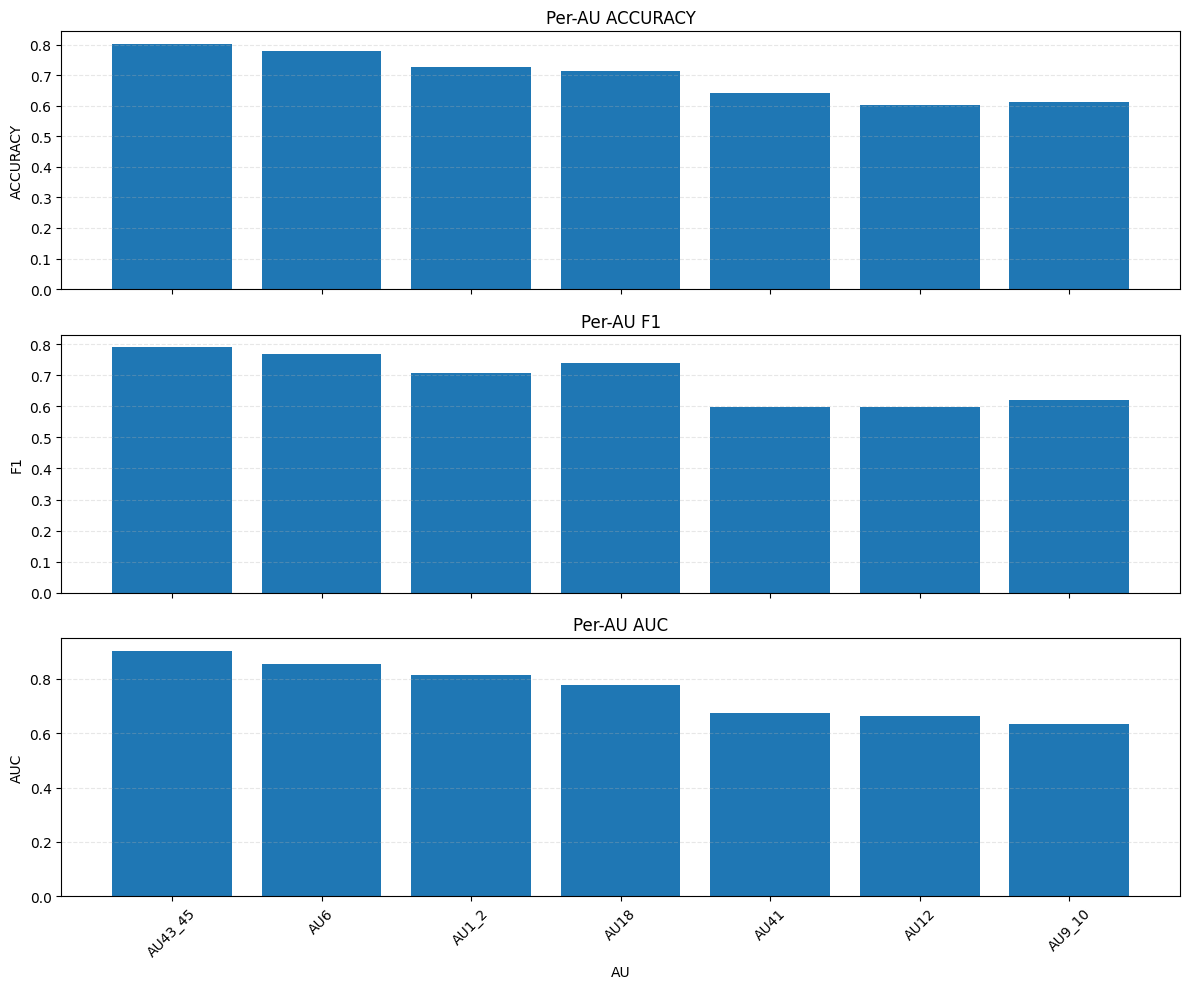

In [4]:
# plots
utils_plots.plot_per_au_results(df_per_au)
# utils_plots.plot_ablation_results(df_ablate)
# utils_plots.plot_group_rfe(df_rfe)


(<Figure size 1200x1000 with 3 Axes>,
 array([<Axes: title={'center': 'Per-AU ACCURACY'}, ylabel='ACCURACY'>,
        <Axes: title={'center': 'Per-AU F1'}, ylabel='F1'>,
        <Axes: title={'center': 'Per-AU AUC'}, xlabel='AU', ylabel='AUC'>],
       dtype=object))

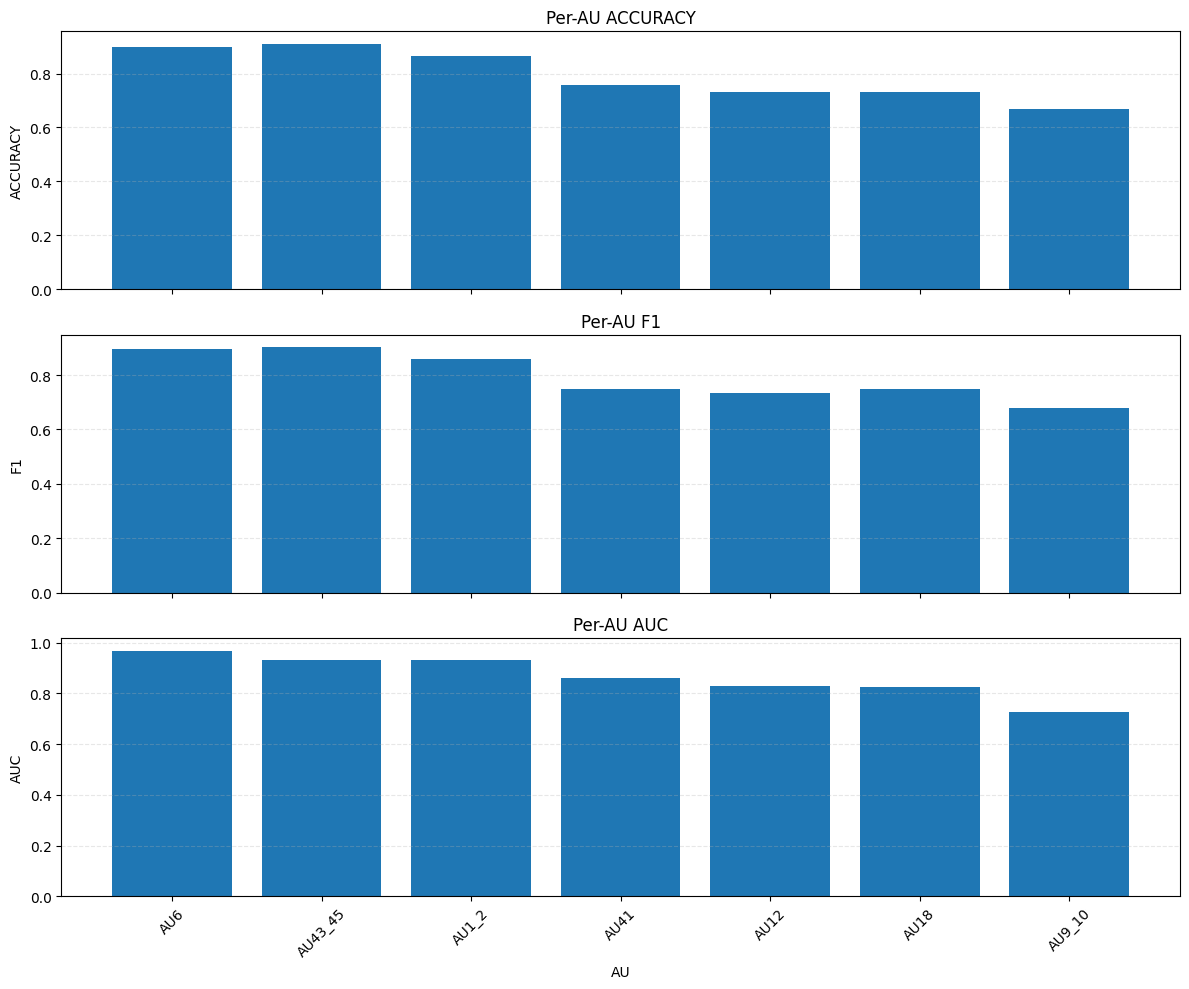

In [6]:
# building datasets
df_feature_flatten = temporal.build_dataset_flatten(
    trial_df=behave_pd,
    csv_pd=csv_pd,
    au_config=AUs,
    fps=fps,
    likelihood_threshold=likelihood_threshold,
)
 

df_feature = temporal.dataset_to_long_format(df_feature_flatten)

# feature classification
results_per_au = modeling.evaluate_per_au(df_feature_flatten)
results_ablate = modeling.evaluate_au_ablation(df_feature_flatten)
results_RFE_group = modeling.group_rfe(df_feature_flatten)

# feature classification dataset
df_per_au = modeling.per_au_results_to_df(results_per_au)
utils_plots.plot_per_au_results(df_per_au)
